# VRChat retention, Part 1: who stays

Companion notebook to Part 1. It rebuilds every number on the page, in the page's order, from the data file.
Run it first: it saves the retention table that the notebooks for Parts 2 and 3 read.

## Load the data

Every public Steam review of VRChat (app 438100), downloaded on 28 Aug 2026. The file has no review text and no review or user IDs; hardware details are kept only as a yes/no flag.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lifelines
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
from lifelines.utils import median_survival_times

print("pandas", pd.__version__, "| numpy", np.__version__, "| lifelines", lifelines.__version__)

raw = pd.read_csv("data/vrchat_steam_reviews.csv.gz")
DOWNLOAD = pd.Timestamp("2026-08-28 06:39")         # when the download finished
END = DOWNLOAD - pd.Timedelta(days=365)              # analysis end: the final year is used only to confirm silence
DAY = 86400                                          # seconds in a day

created = pd.to_datetime(raw["timestamp_created"], unit="s")
updated = pd.to_datetime(raw["timestamp_updated"], unit="s")
last_played = pd.to_datetime(raw["author_last_played"], unit="s")
hours = raw["author_playtime_at_review"] / 60
edited = updated > created
raw.shape

pandas 3.0.5 | numpy 2.5.2 | lifelines 0.30.0


(267904, 24)

## 1. The data

267,904 reviews in 30 languages, 01 Feb 2017 to 28 Aug 2026
English 66% (two thirds), thumbs up 75% (three quarters), median playtime at review 30 hours
reviews per year: {2017: 1543, 2018: 17993, 2019: 14560, 2020: 30618, 2021: 37987, 2022: 63171, 2023: 25416, 2024: 27890, 2025: 29341, 2026: 19385}
reviews posted 25 to 31 July 2022: 21,699


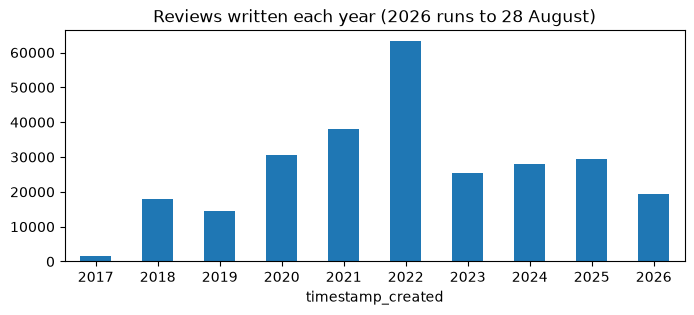

In [2]:
print(f"{len(raw):,} reviews in {raw['language'].nunique()} languages, {created.min():%d %b %Y} to {created.max():%d %b %Y}")
print(f"English {(raw['language'] == 'english').mean():.0%} (two thirds), thumbs up {raw['voted_up'].mean():.0%} (three quarters), "
      f"median playtime at review {hours.median():.0f} hours")

per_year = created.dt.year.value_counts().sort_index()
print("reviews per year:", per_year.to_dict())
print(f"reviews posted 25 to 31 July 2022: {((created >= '2022-07-25') & (created < '2022-08-01')).sum():,}")

per_year.plot.bar(figsize=(8, 3), rot=0, title="Reviews written each year (2026 runs to 28 August)")
plt.show()

## 2. Three fixes before any model

### Use only inputs known when the clock starts
Total playtime was measured at the download, so it already holds part of the future.

In [3]:
print(f"total playtime bigger than playtime at review: {(raw['author_playtime_forever'] > raw['author_playtime_at_review']).mean():.1%}")

download_day = ["author_playtime_forever", "author_playtime_last_two_weeks", "author_num_games_owned", "author_num_reviews"]
votes = ["votes_up", "votes_funny", "weighted_vote_score", "comment_count"]
constant = [c for c in raw if raw[c].nunique(dropna=False) == 1]
filled = {c: int(raw[c].sum() if raw[c].dtype == bool else raw[c].notna().sum()) for c in raw}
rare = {c: n for c, n in filled.items() if n < 0.01 * len(raw) and c not in constant}
print("dropped, measured on the download day:", download_day)
print("dropped, votes from other readers that keep growing:", votes)
print("dropped, the same for everyone:", constant)
print("dropped, filled for under 1% of reviews:", rare)

languages = raw["language"].value_counts()
print(f"kept: playtime at review, the thumbs, and the language as English or not "
      f"({(languages < 1000).sum()} of the {len(languages)} languages have fewer than 1,000 reviews)")

total playtime bigger than playtime at review: 90.7%
dropped, measured on the download day: ['author_playtime_forever', 'author_playtime_last_two_weeks', 'author_num_games_owned', 'author_num_reviews']
dropped, votes from other readers that keep growing: ['votes_up', 'votes_funny', 'weighted_vote_score', 'comment_count']
dropped, the same for everyone: ['steam_purchase', 'received_for_free', 'refunded', 'written_during_early_access', 'app_release_date']
dropped, filled for under 1% of reviews: {'primarily_steam_deck': 286, 'author_deck_playtime_at_review': 2569, 'has_hardware': 2318, 'bBeWary': 2, 'timestamp_dev_responded': 4}
kept: playtime at review, the thumbs, and the language as English or not (15 of the 30 languages have fewer than 1,000 reviews)


### Edits reset playtime at review
Test: people who played after posting and stopped before editing. Their two playtimes can only match if Steam reset the first one at the edit.

edited reviews: 18%
reviews edited since 29 Aug 2024: 19,655 (7.3% of the data)
edits that match, before 29 Aug 2024: 18%
edits that match, from 29 Aug 2024 to the download: 96%
never edited reviews whose authors played after posting, matching: 0.7%
share matching: 2024-05 13%, 2024-06 25%, 2024-07 8%, 2024-08 26%, 2024-09 100%, 2024-10 100%, 2024-11 100%, 2024-12 100%
edits behind each month: 2024-05 31, 2024-06 32, 2024-07 38, 2024-08 27, 2024-09 33, 2024-10 29, 2024-11 38, 2024-12 48


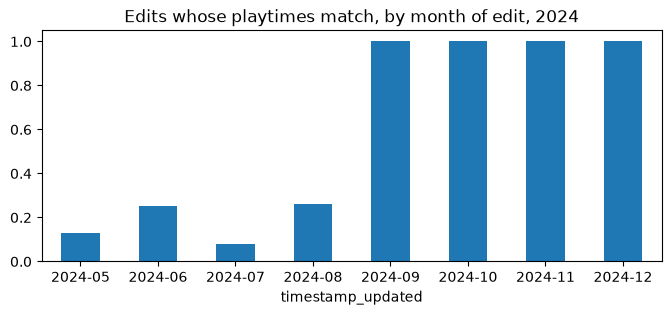

In [4]:
test = edited & (last_played > created) & (last_played <= updated)
same = raw["author_playtime_at_review"] == raw["author_playtime_forever"]
switch = updated >= "2024-08-29"

print(f"edited reviews: {edited.mean():.0%}")
print(f"reviews edited since 29 Aug 2024: {(edited & switch).sum():,} ({(edited & switch).mean():.1%} of the data)")
print(f"edits that match, before 29 Aug 2024: {same[test & ~switch].mean():.0%}")
print(f"edits that match, from 29 Aug 2024 to the download: {same[test & switch].mean():.0%}")
print(f"never edited reviews whose authors played after posting, matching: {same[~edited & (last_played > created)].mean():.1%}")

by_month = same[test].groupby(updated[test].dt.to_period("M")).agg(["mean", "size"]).loc["2024-05":"2024-12"]
by_month.columns = ["share matching", "edits"]
print("share matching:", ", ".join(f"{m} {v:.0%}" for m, v in by_month["share matching"].items()))
print("edits behind each month:", ", ".join(f"{m} {n}" for m, n in by_month["edits"].items()))
by_month["share matching"].plot.bar(figsize=(8, 3), rot=0, title="Edits whose playtimes match, by month of edit, 2024")
plt.show()

### Confirm each departure with a year without play
First the obvious rule, no play in the 14 days before the download, for people at the same stage (90 days to two years after their review).

two week rule, stops per 1,000 players per day: 2018 0.56, 2019 0.40, 2020 0.41, 2021 0.45, 2022 0.50, 2023 0.35, 2024 0.42, 2025 0.67, 2026 2.70
2018 to 2024: 0.35 to 0.56, average 0.44; 2026 is 6.1 times that


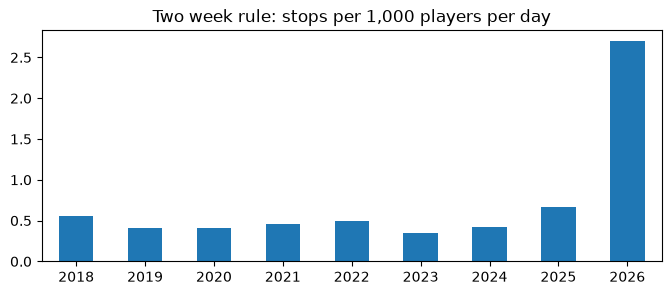

In [5]:
q = pd.DataFrame({"start": updated, "lp": last_played, "created": created, "edited": edited,
                  "author_playtime_at_review": raw["author_playtime_at_review"], "voted_up": raw["voted_up"],
                  "language": raw["language"]})
q = q[raw["author_last_played"] > 0]                 # one review has no session on record

gap = (DOWNLOAD - q["lp"]).dt.total_seconds() / DAY
still14 = gap <= 14
gone14 = (q["lp"] < q["start"]) & ~still14
q["T14"] = np.where(still14, (DOWNLOAD - q["start"]).dt.total_seconds() / DAY,
                    np.where(gone14, 0, (q["lp"] - q["start"]).dt.total_seconds() / DAY))
q["E14"] = (~still14).astype(int)

r14 = q[~gone14]
enters = r14["start"] + pd.Timedelta(days=90)
leaves = r14["start"] + pd.to_timedelta(r14["T14"].clip(upper=730), unit="D")
stop_day = r14["start"] + pd.to_timedelta(r14["T14"], unit="D")
in_stage = (r14["E14"] == 1) & (r14["T14"] >= 90) & (r14["T14"] < 730)

stage = {}
for y in range(2018, 2027):
    y0, y1 = pd.Timestamp(f"{y}-01-01"), min(pd.Timestamp(f"{y + 1}-01-01"), DOWNLOAD)
    days_watched = (leaves.clip(upper=y1) - enters.clip(lower=y0)).dt.total_seconds().clip(lower=0).sum() / DAY
    stage[y] = 1000 * (in_stage & (stop_day >= y0) & (stop_day < y1)).sum() / days_watched

print("two week rule, stops per 1,000 players per day: " + ", ".join(f"{y} {v:.2f}" for y, v in stage.items()))
base = np.mean([stage[y] for y in range(2018, 2025)])
print(f"2018 to 2024: {min(stage[y] for y in range(2018, 2025)):.2f} to {max(stage[y] for y in range(2018, 2025)):.2f}, "
      f"average {base:.2f}; 2026 is {stage[2026] / base:.1f} times that")
pd.Series(stage).plot.bar(figsize=(8, 3), rot=0, title="Two week rule: stops per 1,000 players per day")
plt.show()

The fix: end the analysis a year before the download, on 28 Aug 2025, and count someone as gone only when a full year without play follows their last session.

In [6]:
d = q[q["start"] < END].copy()
still = d["lp"] >= END                               # seen playing after the analysis end
gone0 = d["lp"] < d["start"]                         # already gone: last session before the clock starts
d["T"] = np.where(still, (END - d["start"]).dt.total_seconds() / DAY,
                  np.where(gone0, 0, (d["lp"] - d["start"]).dt.total_seconds() / DAY))
d["event"] = (~still).astype(int)

print(f"analysis end: {END:%d %b %Y}")
print(f"clock starts in the final year, can't be measured yet: {(updated >= END).sum():,} "
      f"(older reviews edited then included: {((created < END) & (updated >= END)).sum():,})")

for days in (180, 365, 540):                         # how long a silence is required
    end = DOWNLOAD - pd.Timedelta(days=days)
    x = q[q["start"] < end]
    st = x["lp"] >= end
    T = np.where(st, (end - x["start"]).dt.total_seconds(), (x["lp"] - x["start"]).dt.total_seconds().clip(lower=0)) / DAY
    km = KaplanMeierFitter().fit(T, (~st).astype(int))
    print(f"{days} days of silence: day 90 {km.predict(90):.1%}, median {km.median_survival_time_:,.0f} days")

analysis end: 28 Aug 2025
clock starts in the final year, can't be measured yet: 37,983 (older reviews edited then included: 8,302)
180 days of silence: day 90 81.6%, median 1,088 days
365 days of silence: day 90 82.1%, median 1,165 days


540 days of silence: day 90 82.3%, median 1,216 days


### Start the clock at the last edit
The thumbs, and since Aug 2024 the playtime, belong to the review's last edit.

In [7]:
km = KaplanMeierFitter().fit(d["T"], d["event"])
lo, hi = median_survival_times(km.confidence_interval_).values[0]

first_post = d["created"]                            # the same reviewers, clock at the first post
T_post = np.where(still, (END - first_post).dt.total_seconds(),
                  (d["lp"] - first_post).dt.total_seconds().clip(lower=0)) / DAY
km_post = KaplanMeierFitter().fit(T_post, (~still).astype(int))

print(f"reviews never edited: {1 - edited.mean():.0%}")
print(f"median, clock at the first post: {km_post.median_survival_time_:,.0f} days; at the last edit: {km.median_survival_time_:,.0f}")
print(f"the clock moves the median by {km_post.median_survival_time_ - km.median_survival_time_:.0f} days (about 120); "
      f"the silence rule across 1,216 - 1,088 = {1216 - 1088} days")
print(f"95% confidence interval of the median: {lo:,.0f} to {hi:,.0f} days")

reviews never edited: 82%
median, clock at the first post: 1,287 days; at the last edit: 1,165
the clock moves the median by 122 days (about 120); the silence rule across 1,216 - 1,088 = 128 days
95% confidence interval of the median: 1,157 to 1,173 days


## 3. The retention curve

In [8]:
d["group"] = np.where(still, "still playing", np.where(gone0, "already gone", "left"))
print(f"followed: {len(d):,} = {len(raw):,} - {(updated >= END).sum():,} (clock in the final year) - "
      f"{((updated < END) & (raw['author_last_played'] <= 0)).sum()} (no session on record)")
groups = d["group"].value_counts()
print(pd.DataFrame({"people": groups, "share": (groups / len(d) * 100).round(1)}).to_string())

g = d[gone0]
print(f"already gone whose clock starts at a later edit: {g['edited'].mean():.0%}")
print(f"thumbs up: already gone {g['voted_up'].mean():.0%}, everyone else {d.loc[~gone0, 'voted_up'].mean():.0%}")
down = d["voted_up"] == False
print(f"share of all thumbs down reviews written by the already gone: {(down & gone0).sum() / down.sum():.1%}")

followed: 229,920 = 267,904 - 37,983 (clock in the final year) - 1 (no session on record)
               people  share
group                       
still playing  115113   50.1
left            94968   41.3
already gone    19839    8.6
already gone whose clock starts at a later edit: 15%
thumbs up: already gone 57%, everyone else 78%
share of all thumbs down reviews written by the already gone: 15.7%


Why not a raw churn share or a raw median: both mishandle the people still playing.

In [9]:
year = d["start"].dt.year
for y in (2017, 2025):
    part = d[year == y]
    years_to_leave = ((END - part["start"]).dt.days / 365).median()
    day90 = KaplanMeierFitter().fit(part["T"], part["event"]).predict(90)
    print(f"{y}: counted as gone {part['event'].mean():.1%}, years to leave {years_to_leave:.1f}, still playing at day 90 {day90:.1%}")

print(f"median of raw durations, still playing counted as stopped: {d['T'].median():.0f} days")
print(f"median of raw durations, still playing dropped: {d.loc[d['event'] == 1, 'T'].median():.0f} days")

2017: counted as gone 77.1%, years to leave 7.7, still playing at day 90 79.2%
2025: counted as gone 22.3%, years to leave 0.3, still playing at day 90 79.2%
median of raw durations, still playing counted as stopped: 625 days
median of raw durations, still playing dropped: 310 days


day    0: 91.4% still playing
day    7: 86.9% still playing
day   90: 82.1% still playing
day  365: 72.5% still playing
day 1825: 33.3% still playing
estimated median time to the last observed session: 1,165 days (95% CI 1,157 to 1,173)
points lost from the review to day 90: 9.3, in the first week: 4.5
beyond three years only clocks started before 29 Aug 2022 are followed


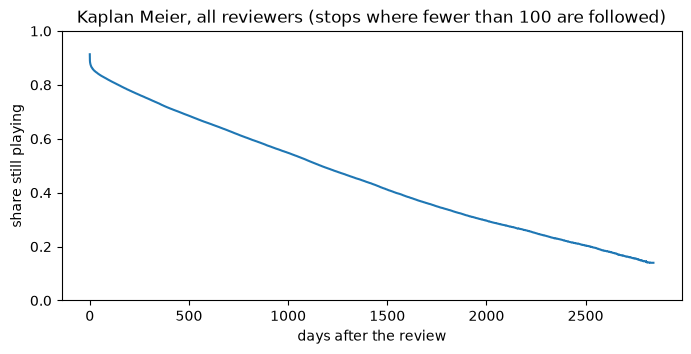

In [10]:
for t in (0, 7, 90, 365, 1825):
    print(f"day {t:>4}: {km.predict(t):.1%} still playing")
print(f"estimated median time to the last observed session: {km.median_survival_time_:,.0f} days (95% CI {lo:,.0f} to {hi:,.0f})")
print(f"points lost from the review to day 90: {100 * (km.predict(0) - km.predict(90)):.1f}, in the first week: {100 * (km.predict(0) - km.predict(7)):.1f}")
print(f"beyond three years only clocks started before {END - pd.Timedelta(days=1095):%d %b %Y} are followed")

at_risk = km.event_table["at_risk"]
shown = km.survival_function_[km.survival_function_.index <= at_risk.index[at_risk >= 100].max()]
plt.figure(figsize=(8, 3.5))
plt.step(shown.index, shown.iloc[:, 0], where="post")
plt.ylim(0, 1)
plt.xlabel("days after the review")
plt.ylabel("share still playing")
plt.title("Kaplan Meier, all reviewers (stops where fewer than 100 are followed)")
plt.show()

## 4. Who keeps playing
Descriptive splits, one input at a time.

### Playtime at review

          band  people  already gone, %  1 year, %  median days
     under 1 h   14422             39.8       32.9          5.9
     1 to 20 h   91832             11.9       59.1        616.8
   20 to 100 h   50599              4.2       79.4       1261.2
100 to 1,000 h   48429              1.7       91.2       2077.3
  over 1,000 h   24523              0.6       96.9          inf
the five curves never cross (days 0 to 3,000): True
under 20 hours: 46% of reviewers, 67% of all stops
top band starting at 900 hours: 96.9% a year later


top band starting at 1,000 hours: 96.9% a year later
top band starting at 1,100 hours: 97.0% a year later


log rank test across the five bands, 229,805 reviewers: p value 0.0


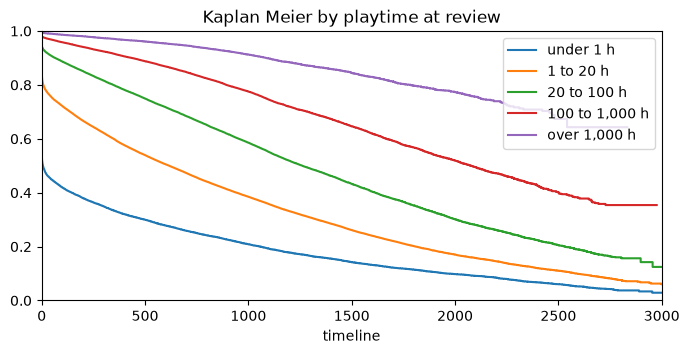

In [11]:
d["hours"] = d["author_playtime_at_review"] / 60
BANDS = ["under 1 h", "1 to 20 h", "20 to 100 h", "100 to 1,000 h", "over 1,000 h"]
d["band"] = pd.cut(d["hours"], [0, 1, 20, 100, 1000, np.inf], labels=BANDS, right=False)

rows, kms = [], {}
for b in BANDS:
    part = d[d["band"] == b]
    kms[b] = KaplanMeierFitter().fit(part["T"], part["event"], label=b)
    rows.append({"band": b, "people": len(part), "already gone, %": round(100 * (part["group"] == "already gone").mean(), 1),
                 "1 year, %": round(100 * kms[b].predict(365), 1), "median days": round(kms[b].median_survival_time_, 1)})
print(pd.DataFrame(rows).to_string(index=False))

grid = np.arange(0, 3001, 5)
curves = np.array([kms[b].survival_function_at_times(grid).values for b in BANDS])
print("the five curves never cross (days 0 to 3,000):", bool((np.diff(curves, axis=0) > 0).all()))

light = d["hours"] < 20
print(f"under 20 hours: {light.mean():.0%} of reviewers, {light[d['event'] == 1].mean():.0%} of all stops")
for edge in (900, 1000, 1100):
    part = d[d["hours"] >= edge]
    print(f"top band starting at {edge:,} hours: {KaplanMeierFitter().fit(part['T'], part['event']).predict(365):.1%} a year later")

has_band = d.dropna(subset=["band"])
p = multivariate_logrank_test(has_band["T"], has_band["band"], has_band["event"]).p_value
print(f"log rank test across the five bands, {len(has_band):,} reviewers: p value {p}")

ax = plt.figure(figsize=(8, 3.5)).gca()
for b in BANDS:
    kms[b].plot_survival_function(ax=ax, ci_show=False)
plt.xlim(0, 3000)
plt.ylim(0, 1)
plt.title("Kaplan Meier by playtime at review")
plt.show()

### The thumbs

thumbs up   a year later: 73.1%
thumbs down a year later: 70.5%
over 1,000 hours: 17.7% of thumbs down reviewers, 8.5% of thumbs up
                1 year, up  already gone, up  1 year if playing at the review, up  1 year, down  already gone, down  1 year if playing at the review, down   gap
band                                                                                                                                                            
under 1 h             35.5              34.5                                 54.2          27.2                51.4                                   56.0   8.3
1 to 20 h             61.5               8.5                                 67.2          47.3                28.7                                   66.3  14.3
20 to 100 h           81.0               2.4                                 83.0          72.8                11.4                                   82.2   8.2
100 to 1,000 h        91.9               0.9                   

1 to 20 h, playing at the review, protest week left out, thumbs up: 67.2% a year later
1 to 20 h, playing at the review, protest week left out, thumbs down: 62.8% a year later


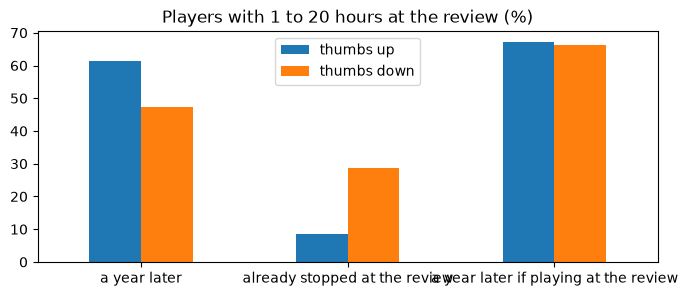

In [12]:
for up in (True, False):
    part = d[d["voted_up"] == up]
    print(f"{'thumbs up  ' if up else 'thumbs down'} a year later: {KaplanMeierFitter().fit(part['T'], part['event']).predict(365):.1%}")
print(f"over 1,000 hours: {(d.loc[d['voted_up'] == False, 'band'] == 'over 1,000 h').mean():.1%} of thumbs down reviewers, "
      f"{(d.loc[d['voted_up'] == True, 'band'] == 'over 1,000 h').mean():.1%} of thumbs up")

rows = []
for b in BANDS:
    row = {"band": b}
    for up in (True, False):
        part = d[(d["band"] == b) & (d["voted_up"] == up)]
        live = part[part["group"] != "already gone"]
        name = "up" if up else "down"
        row[f"1 year, {name}"] = KaplanMeierFitter().fit(part["T"], part["event"]).predict(365)
        row[f"already gone, {name}"] = (part["group"] == "already gone").mean()
        row[f"1 year if playing at the review, {name}"] = KaplanMeierFitter().fit(live["T"], live["event"]).predict(365)
    row["gap"] = row["1 year, up"] - row["1 year, down"]
    rows.append(row)
thumbs = pd.DataFrame(rows).set_index("band")
print((100 * thumbs).round(1).to_string())

protest_week = (d["start"] >= "2022-07-25") & (d["start"] < "2022-08-01")
live_new = d[(d["band"] == "1 to 20 h") & (d["group"] != "already gone") & ~protest_week]
for up in (True, False):
    part = live_new[live_new["voted_up"] == up]
    print(f"1 to 20 h, playing at the review, protest week left out, {'thumbs up' if up else 'thumbs down'}: "
          f"{KaplanMeierFitter().fit(part['T'], part['event']).predict(365):.1%} a year later")

new = (100 * thumbs.loc["1 to 20 h"]).round(1)
pairs = {"a year later": ("1 year, up", "1 year, down"), "already stopped at the review": ("already gone, up", "already gone, down"),
         "a year later if playing at the review": ("1 year if playing at the review, up", "1 year if playing at the review, down")}
pd.DataFrame({k: [new[u], new[w]] for k, (u, w) in pairs.items()}, index=["thumbs up", "thumbs down"]).T.plot.bar(
    figsize=(8, 3), rot=0, title="Players with 1 to 20 hours at the review (%)")
plt.show()

### Language

In [13]:
d["english"] = d["language"] == "english"
for eng in (True, False):
    part = d[d["english"] == eng]
    print(f"{'English        ' if eng else 'other languages'} a year later: {KaplanMeierFitter().fit(part['T'], part['event']).predict(365):.1%}")
print("share writing in English by band:", (100 * d.groupby("band", observed=True)["english"].mean()).round(1).to_dict())

for b in BANDS:
    yr = [KaplanMeierFitter().fit(p["T"], p["event"]).predict(365) for p in (d[(d["band"] == b) & d["english"]], d[(d["band"] == b) & ~d["english"]])]
    print(f"{b:<15} English {yr[0]:.1%}, other {yr[1]:.1%}, gap {100 * (yr[0] - yr[1]):.1f} points")

English         a year later: 75.5%
other languages a year later: 66.5%
share writing in English by band: {'under 1 h': 47.6, '1 to 20 h': 62.2, '20 to 100 h': 70.8, '100 to 1,000 h': 73.1, 'over 1,000 h': 74.1}
under 1 h       English 36.5%, other 29.7%, gap 6.8 points
1 to 20 h       English 61.6%, other 55.1%, gap 6.5 points
20 to 100 h     English 79.7%, other 78.5%, gap 1.3 points
100 to 1,000 h  English 91.1%, other 91.6%, gap -0.5 points
over 1,000 h    English 96.8%, other 97.2%, gap -0.3 points


### The July 2022 protest week (25 to 31 July)

In [14]:
print(f"clocks started that week: {protest_week.sum():,} (reviews posted that week: "
      f"{((created >= '2022-07-25') & (created < '2022-08-01')).sum():,}); median week: {d['start'].dt.to_period('W').value_counts().median():.0f}")
print(f"thumbs down: {1 - d.loc[protest_week, 'voted_up'].mean():.0%} of them, {1 - d.loc[~protest_week, 'voted_up'].mean():.0%} of everyone else")
print(f"over 1,000 hours: {(d.loc[protest_week, 'hours'] >= 1000).mean():.0%} of them, {(d.loc[~protest_week, 'hours'] >= 1000).mean():.0%} of everyone else")

other_weeks = (d["start"] >= "2022-06-01") & (d["start"] < "2022-10-01") & ~protest_week     # June to September 2022
one_year = lambda m: KaplanMeierFitter().fit(d.loc[m, "T"], d.loc[m, "event"]).predict(365)
print(f"a year later: protest week {one_year(protest_week):.1%}, other weeks of June to September 2022 {one_year(other_weeks):.1%}")
for b in BANDS:
    a, o = one_year(protest_week & (d["band"] == b)), one_year(other_weeks & (d["band"] == b))
    print(f"{b:<15} protest week {a:.1%}, other weeks {o:.1%}, difference {100 * (a - o):+.1f} points")

clocks started that week: 19,959 (reviews posted that week: 21,699); median week: 528
thumbs down: 91% of them, 17% of everyone else
over 1,000 hours: 26% of them, 9% of everyone else
a year later: protest week 83.6%, other weeks of June to September 2022 73.8%
under 1 h       protest week 31.8%, other weeks 30.7%, difference +1.1 points
1 to 20 h       protest week 55.3%, other weeks 55.9%, difference -0.6 points
20 to 100 h     protest week 79.2%, other weeks 79.2%, difference -0.0 points
100 to 1,000 h  protest week 93.3%, other weeks 91.0%, difference +2.3 points
over 1,000 h    protest week 98.0%, other weeks 98.0%, difference +0.0 points


## Save the retention table for Parts 2 and 3
One row per reviewer followed: clock start, last session, T (days followed), event (1 = stopped), group and the three inputs.

In [15]:
keep = ["start", "lp", "edited", "T", "event", "group", "author_playtime_at_review", "voted_up", "language"]
d[keep].rename(columns={"lp": "last_played"}).to_csv("data/retention_table.csv", index=False)
d[keep].shape

(229920, 9)